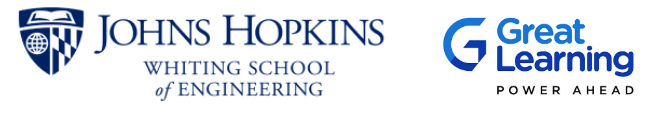

<font size=6>**Finetuning LLM**</font>

<font size=5>**Fine-Tuned AI for Summarizing Insurance Sales Conversations**</font>

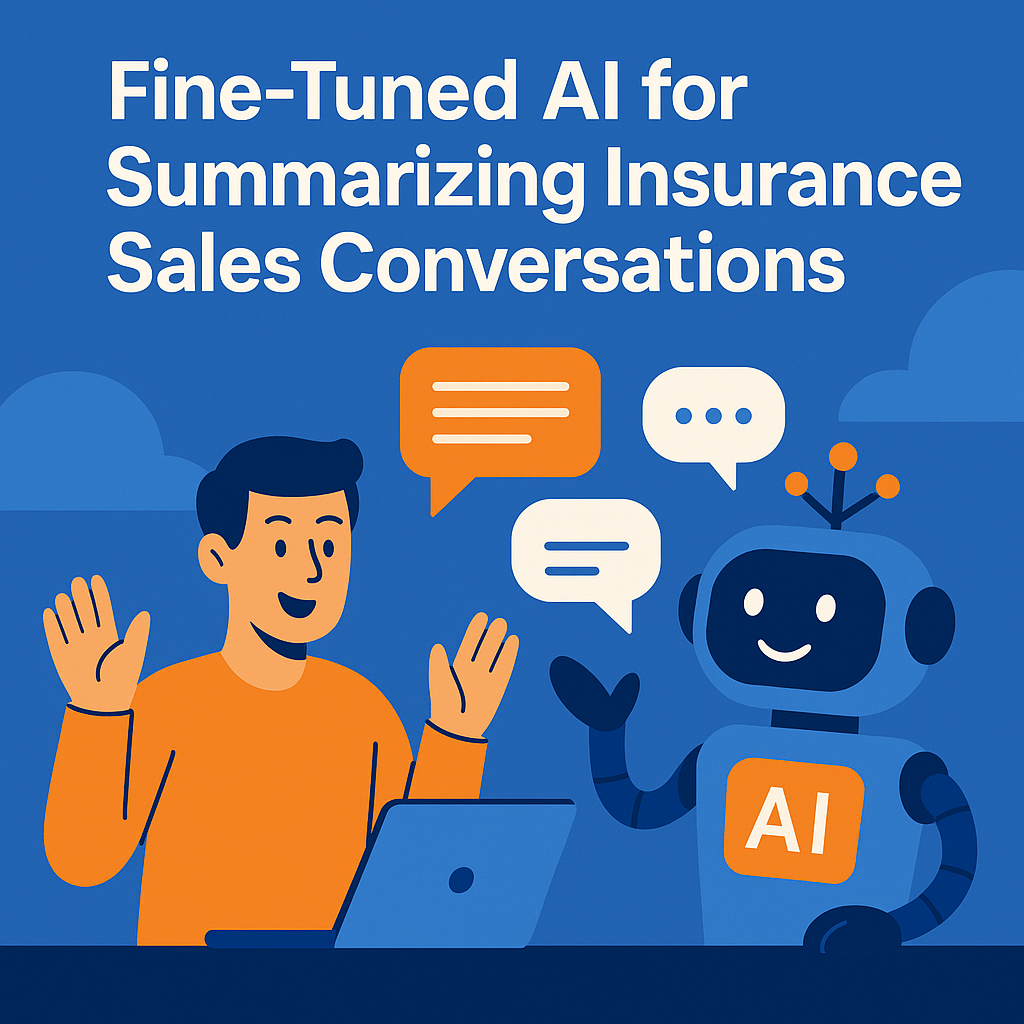

In a bustling regional office of a global insurance provider, Maria, an enterprise sales representative, is preparing for a crucial renewal meeting with one of her largest clients. Over the past year, she’s exchanged dozens of emails, held multiple calls, and met the client twice in person. The problem? All that valuable context is scattered across her inbox, CRM logs, and call notes.

With limited time and growing pressure to personalize service and identify cross-sell opportunities, Maria struggles to recall what matters most—what products the client was interested in, what concerns they raised last quarter, and what promises she made during the last meeting.

What she needs is a smart assistant—one that can synthesize these multi-modal conversations and give her a precise, tailored summary before every touchpoint.

<br>

#### **Business Challenge:**

In the insurance sector, client interactions are rich but fragmented. Sales teams face critical challenges:

1. Information overload from high volumes of unstructured communication data.

2. No standardized way to generate accurate, context-aware summaries.

3. Manual review of emails, call transcripts, and meeting notes is time-consuming and error-prone.

4. Missed opportunities for upsell, poor personalization, and diminished client trust due to incomplete recall.

This leads to inconsistent client engagement, inefficient preparation, and lost revenue opportunities.

#### **Solution**
Provide a Custom Fine-Tuned AI Model for Sales Interaction Summarization

To address this challenge, we propose training a domain-specific fine-tuned language model tailored for enterprise insurance communication.
The model will:

1. Ingest few multi-modal inputs (emails, transcripts, notes).
2. Identify intent, extract key discussion points, client interests, pain points, and commitments.
3. Generate concise, actionable summaries under 200 words, customized for enterprise insurance workflows.
4. Be fine-tuned on real-world communication data to learn domain-specific vocabulary and interaction patterns.

This AI-powered tool will augment sales productivity, enhance client engagement, and ensure consistent follow-ups—turning scattered conversations into strategic intelligence.

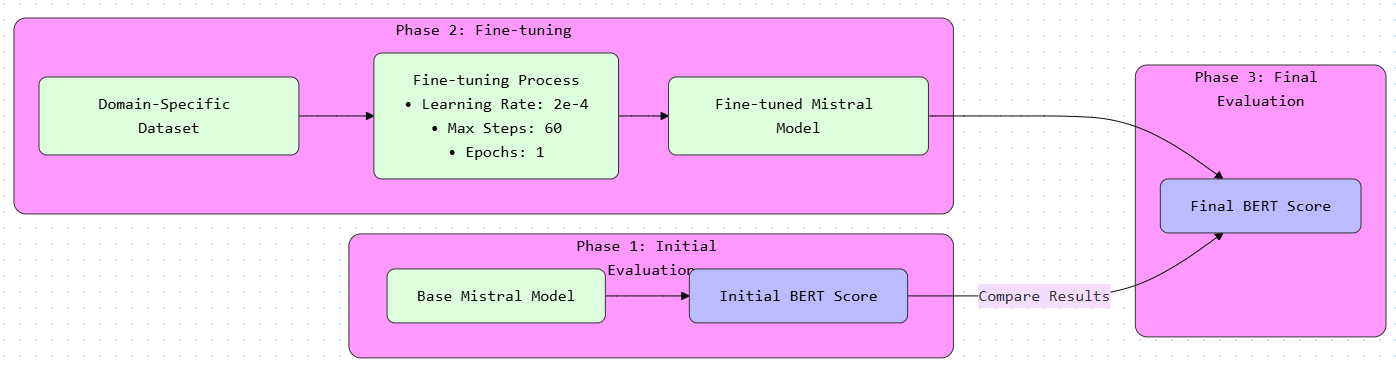

# **Setup**

In [ ]:
# @title Click run for setup
%%capture
 # Do this only in Colab notebooks! Otherwise use pip install unsloth
!pip install --no-deps bitsandbytes accelerate xformers==0.0.29.post3 peft trl==0.15.2 triton cut_cross_entropy unsloth_zoo
!pip install sentencepiece protobuf "datasets>=3.4.1" huggingface_hub hf_transfer
!pip install transformers==4.51.3
!pip install --no-deps unsloth

!pip install -q datasets evaluate bert-score

In [ ]:
! pip show unsloth

In [ ]:
# @title Imports
from unsloth import FastLanguageModel
import torch
import evaluate
from tqdm import tqdm
import pandas as pd
from datasets import Dataset

from trl import SFTTrainer
from transformers import TrainingArguments, EarlyStoppingCallback, DataCollatorForSeq2Seq
from unsloth import is_bfloat16_supported

# **1. Evaluation of LLM before FineTuning**

### Loading the Testing Data


In [ ]:
testing_data = pd.read_csv("/content/finetuning_testing.csv")

test_dialogues = [sample for sample in testing_data['Dialogues']]
test_summaries = [sample for sample in testing_data['Summary']]

### Loading the Mistral Vanilla Model

In [ ]:
model, tokenizer = FastLanguageModel.from_pretrained(
    model_name="unsloth/mistral-7b-instruct-v0.2-bnb-4bit",
    max_seq_length=4096,
    dtype=None,
    load_in_4bit=True
)

In [ ]:
FastLanguageModel.for_inference(model)

### Inference


In [ ]:
summarization_prompt_template = """[INST]
Summarize the dialogue mentioned in the user input. Be specific and concise in your summary.
Ensure that you retain the entities mentioned in the dialogue in your summary.

### User Input:
{dialogue}
[/INST]
"""

In [ ]:
predicted_summaries = []

In [ ]:
for gold_dialogue in tqdm(test_dialogues):

    try:
        prompt = summarization_prompt_template.format(dialogue=gold_dialogue)
        inputs = tokenizer(prompt, return_tensors="pt").to("cuda")

        outputs = model.generate(
            **inputs,
            max_new_tokens=128,
            use_cache=True,
            temperature=0,
            pad_token_id=tokenizer.eos_token_id
        )

        prediction = tokenizer.decode(
            outputs[0][inputs.input_ids.shape[-1]:],
            skip_special_tokens=True,
            cleanup_tokenization_spaces=True
        )

        predicted_summaries.append(prediction)

    except Exception as e:
        print(e) # log error and continue
        continue

### Evaluation


In [ ]:
predicted_summaries

**BERTScore is a metric for evaluating the quality of text generation by comparing the similarity of contextualized word embeddings from a model like BERT. Unlike traditional metrics like BLEU, BERTScore captures semantic similarity, making it more effective for assessing meaning preservation in NLP tasks.**



In [ ]:
bert_scorer = evaluate.load("bertscore")

In [ ]:
score = bert_scorer.compute(
    predictions=predicted_summaries,
    references=test_summaries,
    lang='en',
    rescale_with_baseline=True
)

In [ ]:
sum(score['f1'])/len(score['f1'])

<font size=10 color="BLUE">**The BERT Score of Mistral Vanilla LLM is <font color="red"> 0.16**</font>


# **2. FineTuning an LLM**

### Data Preparation

In [ ]:
training = pd.read_csv("/content/finetuning_training.csv")
training_dict = training.to_dict(orient='list')

# Create a dataset from the dictionary
training_dataset = Dataset.from_dict(training_dict)

In [ ]:
EOS_TOKEN = tokenizer.eos_token

The Alpaca instruction prompt is a general purpose prompt template that can be adapted to any task.

In [ ]:
alpaca_prompt = """Below is an instruction that describes a task, paired with an input that provides further context. Write a response that appropriately completes the request.

### Instruction:
{}

### Input:
{}

### Response:
{}"""

In [ ]:
def prompt_formatter(example, prompt_template):
    instruction='Write a concise summary of the following dialogue.'
    dialogue=example["Dialogues"]
    summary=example["Summary"]

    formatted_prompt = prompt_template.format(instruction, dialogue, summary) + EOS_TOKEN

    return {'text': formatted_prompt}

Notice how we are adding the end-of-sequence token to the prompt i.e. we're adding a special marker at the end of the prompt to show it's finished

In [ ]:
formatted_training_dataset = training_dataset.map(
    prompt_formatter,
    fn_kwargs={'prompt_template': alpaca_prompt}
)

In [ ]:
validation=pd.read_csv("/content/finetuning_validation.csv")
validation_dict =validation.to_dict(orient='list')

# Create a dataset from the dictionary
validation_dataset = Dataset.from_dict(validation_dict)

In [ ]:
formatted_validation_dataset = validation_dataset.map(
    prompt_formatter,
    fn_kwargs={'prompt_template': alpaca_prompt}
)

### Fine-Tuning

We now patch in the adapter modules to the base model using the `get_peft_model` method.

> Practical Tip: $r$ defines the dimensions of the low-rank matrices, while $\alpha$ determines the scaling factor for the weight matrices. It is common to freeze $\alpha=16$, while varying the values of $r = \alpha, \alpha/2, \alpha/4$ and arriving at the optimal value of that gives the lowest validation loss (note that we use the same loss used for the base model, e.g., perplexity or log loss).

In [ ]:
model = FastLanguageModel.get_peft_model(
    model,
    r=16,
    lora_alpha=16,
    lora_dropout=0,
    bias="none",
    target_modules = ["q_proj", "k_proj", "v_proj", "o_proj",
                      "gate_proj", "up_proj", "down_proj"],
    use_gradient_checkpointing=True,
    random_state=42,
    loftq_config=None
)

In [ ]:
model

The **architecture** of the Mistral model, specifically the MistralForCausalLM, consists of several key components:

1) Embedding Layer: The model starts with an embedding layer that converts input tokens into a dense representation with an output size of 4096, supporting a vocabulary of 32,000 tokens.

2) Decoder Layers: The core of the model comprises 32 MistralDecoderLayer instances, each containing:
- Self-Attention Mechanism: This includes multiple projection layers for queries,
keys, values, and output, all designed to handle 4-bit precision for efficient computation. Rotary embeddings are also employed for position encoding.
- Feedforward Network (MLP): The MLP features gates and projections to expand the dimensionality to 14,336 before reducing it back to 4096, using the SiLU activation function.
- Layer Normalization: Each decoder layer includes input and post-attention normalization using MistralRMSNorm.

3) Final Normalization: The entire model concludes with an additional normalization layer.

4) Linear Output Head: The model includes a linear layer that maps the 4096-dimensional output back to the token vocabulary size (32,000), enabling the generation of predictions.

<br>

Notice how LoRA adapters are attached to the layers specified during instantiation.

<br>

For training, we use the following nuances borrowed from the broader deep learning discipline.

- Low learning rates for smooth parameter updates
- Early stopping to monitor for validation loss (negative log likelihood in this case)
- Checkpointing to enable resumption of training


In [ ]:
trainer = SFTTrainer(
    model = model,
    tokenizer = tokenizer,
    train_dataset = formatted_training_dataset,
    eval_dataset = formatted_validation_dataset,
    dataset_text_field = "text",
    max_seq_length = 2048,
    data_collator = DataCollatorForSeq2Seq(tokenizer=tokenizer),
    dataset_num_proc = 2,
    packing = False, # Can make training 5x faster for short sequences.
    args = TrainingArguments(
        per_device_train_batch_size = 2,
        gradient_accumulation_steps = 4,
        warmup_steps = 5,
        num_train_epochs = 2, # Set this for 1 full training run.
        max_steps = 60,
        learning_rate = 2e-4,
        fp16 = not is_bfloat16_supported(),
        bf16 = is_bfloat16_supported(),
        logging_steps = 1,
        optim = "adamw_8bit",
        weight_decay = 0.01,
        lr_scheduler_type = "linear",
        seed = 3407,
        output_dir = "outputs",
        report_to = "none"
    ),
)

In this code snippet, we **are performing fine-tuning of the model for 60 steps instead of a full epoch**. The reason for limiting the training to 60 steps is to provide a quick demonstration of the fine-tuning process without extensive time commitment. Running it for a full epoch can be time-consuming, especially with large datasets and models.

**Steps** refer to the individual training iterations where a batch of data is processed and model weights are updated, while an **epoch** represents a full pass through the entire training dataset. Essentially, an epoch consists of multiple steps. Using steps allows for finer control over training duration and enables quicker adjustments without running through the entire dataset.

To clarify further, if you wish to conduct a complete training run for a better fine-tuning effect, they can easily do so by **uncommenting the line num_train_epochs = 1 in the TrainingArguments**

In [ ]:
training_history = trainer.train()

### Saving the Trained Model
We will be saving this fine tuned model in our google drive so that we can test/evaluate this model. As finetuning is an expensive process, its best to save the model, in case of crashes

In [ ]:
# @title Setup to enable bash commands
import locale

def getpreferredencoding():
    return "UTF-8"

locale.getpreferredencoding = getpreferredencoding

In [ ]:
lora_model_name = "MLS_15_finetuned_mistral_llm"
model.save_pretrained(lora_model_name)
!ls -lh {lora_model_name}

# **3. Evaluation of LLM after FineTuning**

### Loading the Testing Data

In [ ]:
testing_data = pd.read_csv("/content/finetuning_testing.csv")

test_dialogues = [sample for sample in testing_data['Dialogues']]
test_summaries = [sample for sample in testing_data['Summary']]

### Loading the Finetuned Mistral LLM

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
# You may also load the LLM directly from /content/ without loading your Google Drive by changing the location with the following -
# /content/MLS_15_finetuned_mistral_llm

In [ ]:
!cp -r {lora_model_name} /content/drive/MyDrive/MLS_15_finetuned_llm/

In [ ]:
model, tokenizer = FastLanguageModel.from_pretrained(
    model_name=lora_model_name,
    max_seq_length=2048,
    dtype=None,
    load_in_4bit=True
)

### Inferencing

In [ ]:
alpaca_prompt_template = """Below is an instruction that describes a task, paired with an input that provides further context. Write a response that appropriately completes the request.

### Instruction:
Write a concise summary of the following dialogue.

### Input:
{}

### Response:
{}
"""

In [ ]:
predicted_summaries = []

In [ ]:
for gold_dialogue in tqdm(test_dialogues):

    try:
        prompt = alpaca_prompt_template.format(gold_dialogue, '')
        inputs = tokenizer(prompt, return_tensors="pt").to("cuda")

        outputs = model.generate(
            **inputs,
            max_new_tokens=128,
            use_cache=True,
            temperature=0,
            pad_token_id=tokenizer.eos_token_id
        )

        prediction = tokenizer.decode(
            outputs[0][inputs.input_ids.shape[-1]:],
            skip_special_tokens=True,
            cleanup_tokenization_spaces=True
        )

        predicted_summaries.append(prediction)

    except Exception as e:
        print(e) # log error and continue
        continue

### Evaluation

In [ ]:
predicted_summaries

In [ ]:
score = bert_scorer.compute(
    predictions=predicted_summaries,
    references=test_summaries,
    lang='en',
    rescale_with_baseline=True
)


In [ ]:
sum(score['f1'])/len(score['f1'])

<font size=10 color="BLUE">**The BERT Score of Finetuned Mistral LLM is <font color="red"> 0.5**</font>



### **Conclusion**

**We observed a significant improvement in the BERTScore after fine-tuning the Mistral model, also an observation can be made on the Predicted Summaries**

Previously, the generated summaries of client interactions were overly verbose and lacked alignment with user preferences and domain-specific needs. By fine-tuning a language model on task-relevant and insurance-specific communication data, we significantly improved the model's ability to generate concise, actionable, and context-aware summaries. The fine-tuned model now produces outputs that are not only more relevant and structured but also tailored to user expectations—enhancing sales productivity and ensuring better client engagement in the insurance domain.